In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
df = pd.read_parquet('yellow_tripdata_2023-12.parquet')
df = df.sample(n=500000, random_state=42)
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
df['trip_duration_minutes'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

In [4]:
df_clean = df[
    (df['trip_duration_minutes'] >= 1) &
    (df['trip_duration_minutes'] <= 180) &
    (df['trip_distance'] > 0) &
    (df['passenger_count'] > 0)
].copy()
print("Clean rows:", len(df_clean))

Clean rows: 458526


In [7]:
zones = pd.read_csv('taxi_zone_lookup.csv')
zones['LocationID'] = zones['LocationID'].astype('Int64')
df_clean['PULocationID'] = df_clean['PULocationID'].astype('Int64')
df_clean['DOLocationID'] = df_clean['DOLocationID'].astype('Int64')

df_clean = df_clean.merge(zones[['LocationID','Borough']], left_on='PULocationID', right_on='LocationID', how='left')
df_clean = df_clean.rename(columns={'Borough':'pickup_borough'}).drop(columns=['LocationID'])

df_clean = df_clean.merge(zones[['LocationID','Borough']], left_on='DOLocationID', right_on='LocationID', how='left')
df_clean = df_clean.rename(columns={'Borough':'dropoff_borough'}).drop(columns=['LocationID'])

In [8]:
df_clean['pickup_hour'] = df_clean['tpep_pickup_datetime'].dt.hour
df_clean['pickup_month'] = df_clean['tpep_pickup_datetime'].dt.month
df_clean['pickup_dayofweek'] = df_clean['tpep_pickup_datetime'].dt.dayofweek
df_clean['is_weekend'] = df_clean['pickup_dayofweek'].isin([5,6]).astype(int)
df_clean['is_peak_hour'] = df_clean['pickup_hour'].apply(lambda h: 1 if (7<=h<=9) or (16<=h<=19) else 0)
df_clean['is_night'] = df_clean['pickup_hour'].apply(lambda h: 1 if (h>=22 or h<=5) else 0)
df_clean['hour_sin'] = np.sin(2 * np.pi * df_clean['pickup_hour'] / 24)
df_clean['hour_cos'] = np.cos(2 * np.pi * df_clean['pickup_hour'] / 24)
df_clean['same_borough'] = (df_clean['pickup_borough'] == df_clean['dropoff_borough']).astype(int)
df_clean['is_pickup_manhattan'] = (df_clean['pickup_borough'] == 'Manhattan').astype(int)

airport_zones = [1, 132, 138]
df_clean['is_airport_route'] = (df_clean['PULocationID'].isin(airport_zones) | df_clean['DOLocationID'].isin(airport_zones)).astype(int)
df_clean['route_pair'] = df_clean['PULocationID'].astype(str) + '_' + df_clean['DOLocationID'].astype(str)

In [9]:
df_clean = df_clean.sort_values('tpep_pickup_datetime')
split_date = df_clean['tpep_pickup_datetime'].quantile(0.8)
train = df_clean[df_clean['tpep_pickup_datetime'] <= split_date]
test = df_clean[df_clean['tpep_pickup_datetime'] > split_date]

In [10]:
safe_features = ['passenger_count', 'PULocationID', 'DOLocationID', 'pickup_hour', 'pickup_month',
                  'pickup_dayofweek', 'is_weekend', 'is_peak_hour', 'is_night', 'hour_sin', 'hour_cos',
                  'same_borough', 'is_pickup_manhattan', 'is_airport_route', 'pickup_borough',
                  'dropoff_borough', 'VendorID', 'RatecodeID']
target = 'trip_duration_minutes'

X_train, y_train = train[safe_features], train[target]
X_test, y_test = test[safe_features], test[target]

categorical_features = ['pickup_borough', 'dropoff_borough', 'VendorID', 'RatecodeID', 'PULocationID', 'DOLocationID']
numeric_features = ['passenger_count', 'pickup_hour', 'pickup_month', 'pickup_dayofweek', 'is_weekend',
                     'is_peak_hour', 'is_night', 'hour_sin', 'hour_cos', 'same_borough', 
                     'is_pickup_manhattan', 'is_airport_route']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [11]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'Elastic Net': ElasticNet(alpha=0.1, l1_ratio=0.5),
}

results = {}
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    results[name] = mae
    print(f"{name} MAE: {mae:.3f}")

Linear Regression MAE: 7.264
Ridge MAE: 7.262
Lasso MAE: 7.596
Elastic Net MAE: 7.593


In [12]:
print("--- Model Comparison ---")
print(f"Baseline (Hour+Route): 4.186")
for name, mae in results.items():
    print(f"{name}: {mae:.3f}")

--- Model Comparison ---
Baseline (Hour+Route): 4.186
Linear Regression: 7.264
Ridge: 7.262
Lasso: 7.596
Elastic Net: 7.593


In [14]:
# Decision Tree
dt_pipeline = Pipeline(steps=[('preprocessor', preprocessor), 
                                ('regressor', DecisionTreeRegressor(max_depth=10, random_state=42))])
dt_pipeline.fit(X_train, y_train)
pred_dt = dt_pipeline.predict(X_test)
mae_dt = mean_absolute_error(y_test, pred_dt)
results['Decision Tree'] = mae_dt
print("Decision Tree MAE:", mae_dt)

# Random Forest
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), 
                                ('regressor', RandomForestRegressor(n_estimators=50, max_depth=15, 
                                                                      random_state=42, n_jobs=-1))])
rf_pipeline.fit(X_train, y_train)
pred_rf = rf_pipeline.predict(X_test)
mae_rf = mean_absolute_error(y_test, pred_rf)
results['Random Forest'] = mae_rf
print("Random Forest MAE:", mae_rf)

Decision Tree MAE: 7.189058290943081
Random Forest MAE: 6.91819905363199


In [17]:
from sklearn.preprocessing import OrdinalEncoder

preprocessor_tree = ColumnTransformer(transformers=[
    ('num', 'passthrough', numeric_features),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
])

In [18]:
gb_pipeline = Pipeline(steps=[('preprocessor', preprocessor_tree), 
                                ('regressor', HistGradientBoostingRegressor(max_iter=100, random_state=42))])
gb_pipeline.fit(X_train, y_train)
pred_gb = gb_pipeline.predict(X_test)
mae_gb = mean_absolute_error(y_test, pred_gb)
results['Gradient Boosting'] = mae_gb
print("Gradient Boosting MAE:", mae_gb)

Gradient Boosting MAE: 6.490923556318322


In [20]:
dt_pipeline = Pipeline(steps=[('preprocessor', preprocessor_tree), 
                                ('regressor', DecisionTreeRegressor(max_depth=10, random_state=42))])
dt_pipeline.fit(X_train, y_train)
pred_dt = dt_pipeline.predict(X_test)
mae_dt = mean_absolute_error(y_test, pred_dt)
results['Decision Tree'] = mae_dt
print("Decision Tree MAE:", mae_dt)

rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor_tree), 
                                ('regressor', RandomForestRegressor(n_estimators=50, max_depth=15, 
                                                                      random_state=42, n_jobs=-1))])
rf_pipeline.fit(X_train, y_train)
pred_rf = rf_pipeline.predict(X_test)
mae_rf = mean_absolute_error(y_test, pred_rf)
results['Random Forest'] = mae_rf
print("Random Forest MAE:", mae_rf)

Decision Tree MAE: 7.012789308161619
Random Forest MAE: 6.049887360056288


In [19]:
print("\n--- FULL MODEL COMPARISON ---")
print(f"Baseline (Hour+Route): 4.186")
for name, mae in sorted(results.items(), key=lambda x: x[1]):
    print(f"{name}: {mae:.3f}")


--- FULL MODEL COMPARISON ---
Baseline (Hour+Route): 4.186
Gradient Boosting: 6.491
Random Forest: 6.918
Decision Tree: 7.189
Ridge: 7.262
Linear Regression: 7.264
Elastic Net: 7.593
Lasso: 7.596


In [21]:
# Train data se route-level median duration nikalen (leakage se bachne ke liye sirf train se)
route_medians = train.groupby('route_pair')['trip_duration_minutes'].median()

train['route_median_duration'] = train['route_pair'].map(route_medians)
test['route_median_duration'] = test['route_pair'].map(route_medians)
test['route_median_duration'] = test['route_median_duration'].fillna(train['trip_duration_minutes'].median())  # naye routes ke liye fallback

# Ab is feature ko add kar ke Gradient Boosting dobara train karen
numeric_features_v2 = numeric_features + ['route_median_duration']
X_train_v2 = train[safe_features + ['route_median_duration']]
X_test_v2 = test[safe_features + ['route_median_duration']]

preprocessor_tree_v2 = ColumnTransformer(transformers=[
    ('num', 'passthrough', numeric_features_v2),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
])

gb_v2 = Pipeline(steps=[('preprocessor', preprocessor_tree_v2), 
                          ('regressor', HistGradientBoostingRegressor(max_iter=100, random_state=42))])
gb_v2.fit(X_train_v2, y_train)
pred_gb_v2 = gb_v2.predict(X_test_v2)
mae_gb_v2 = mean_absolute_error(y_test, pred_gb_v2)
print("Gradient Boosting + Historical Feature MAE:", mae_gb_v2)

Gradient Boosting + Historical Feature MAE: 5.397406480634849


In [22]:
# Train data se route-level median duration nikalen (leakage se bachne ke liye sirf train se)
route_medians = train.groupby('route_pair')['trip_duration_minutes'].median()

train['route_median_duration'] = train['route_pair'].map(route_medians)
test['route_median_duration'] = test['route_pair'].map(route_medians)
test['route_median_duration'] = test['route_median_duration'].fillna(train['trip_duration_minutes'].median())  # naye routes ke liye fallback

# Bonus: Hour + Route median bhi add karen (jo humara best baseline tha)
hour_route_medians = train.groupby(['route_pair','pickup_hour'])['trip_duration_minutes'].median()
train['hour_route_median'] = train.set_index(['route_pair','pickup_hour']).index.map(hour_route_medians)
test['hour_route_median'] = test.set_index(['route_pair','pickup_hour']).index.map(hour_route_medians)
test['hour_route_median'] = test['hour_route_median'].fillna(train['trip_duration_minutes'].median())

# Ab in dono features ko add kar ke Gradient Boosting dobara train karen
numeric_features_v2 = numeric_features + ['route_median_duration', 'hour_route_median']
X_train_v2 = train[safe_features + ['route_median_duration', 'hour_route_median']]
X_test_v2 = test[safe_features + ['route_median_duration', 'hour_route_median']]

preprocessor_tree_v2 = ColumnTransformer(transformers=[
    ('num', 'passthrough', numeric_features_v2),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
])

gb_v2 = Pipeline(steps=[('preprocessor', preprocessor_tree_v2), 
                          ('regressor', HistGradientBoostingRegressor(max_iter=100, random_state=42))])
gb_v2.fit(X_train_v2, y_train)
pred_gb_v2 = gb_v2.predict(X_test_v2)
mae_gb_v2 = mean_absolute_error(y_test, pred_gb_v2)

results['Gradient Boosting + Historical Features'] = mae_gb_v2
print("Gradient Boosting + Historical Features MAE:", mae_gb_v2)
print("\n--- Updated Comparison ---")
print(f"Baseline (Hour+Route): 4.186")
for name, mae in sorted(results.items(), key=lambda x: x[1]):
    print(f"{name}: {mae:.3f}")

Gradient Boosting + Historical Features MAE: 5.83054060363656

--- Updated Comparison ---
Baseline (Hour+Route): 4.186
Gradient Boosting + Historical Features: 5.831
Random Forest: 6.050
Gradient Boosting: 6.491
Decision Tree: 7.013
Ridge: 7.262
Linear Regression: 7.264
Elastic Net: 7.593
Lasso: 7.596


In [23]:
from sklearn.inspection import permutation_importance

# Test set ka chhota sample lete hain speed ke liye
sample_idx = X_test_v2.sample(n=20000, random_state=42).index
X_sample = X_test_v2.loc[sample_idx]
y_sample = y_test.loc[sample_idx]

perm_importance = permutation_importance(gb_v2, X_sample, y_sample, n_repeats=5, random_state=42, n_jobs=-1)

importance_df = pd.DataFrame({
    'feature': X_sample.columns,
    'importance': perm_importance.importances_mean
}).sort_values('importance', ascending=False)

print(importance_df)

                  feature  importance
19      hour_route_median    1.260876
5        pickup_dayofweek    0.046183
18  route_median_duration    0.009586
13       is_airport_route    0.004839
3             pickup_hour    0.004761
17             RatecodeID    0.004647
2            DOLocationID    0.001948
8                is_night    0.000569
15        dropoff_borough    0.000516
0         passenger_count    0.000435
7            is_peak_hour    0.000005
4            pickup_month    0.000000
9                hour_sin   -0.000183
16               VendorID   -0.000289
6              is_weekend   -0.000321
11           same_borough   -0.000472
1            PULocationID   -0.000899
14         pickup_borough   -0.001288
12    is_pickup_manhattan   -0.001513
10               hour_cos   -0.002428


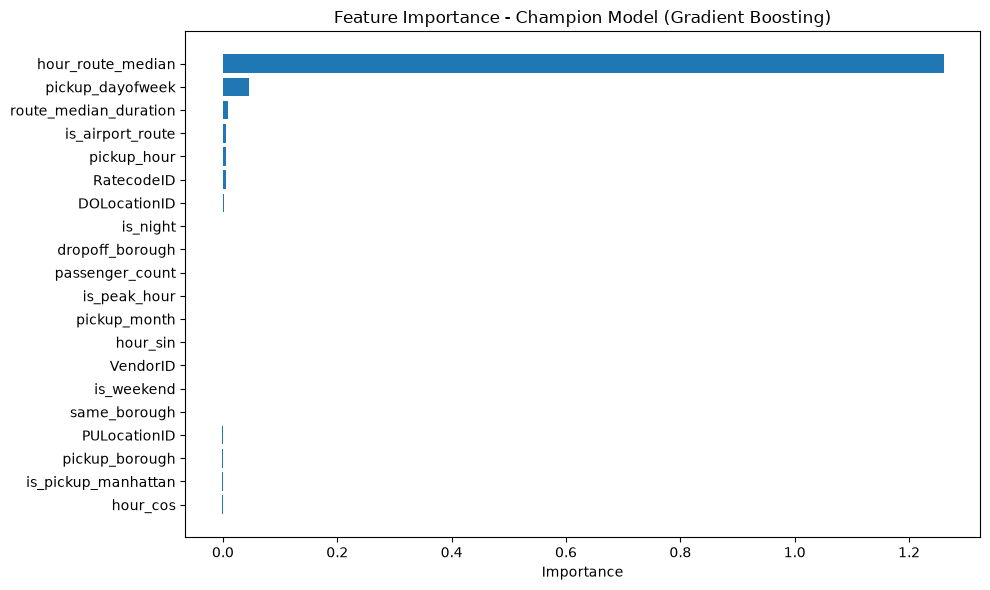

In [24]:
plt.figure(figsize=(10,6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - Champion Model (Gradient Boosting)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [25]:
test_results = test.copy()
test_results['predicted'] = pred_gb_v2
test_results['error'] = test_results['trip_duration_minutes'] - test_results['predicted']
test_results['abs_error'] = test_results['error'].abs()

# Error by hour
error_by_hour = test_results.groupby('pickup_hour')['abs_error'].mean()
print("--- MAE by Hour ---")
print(error_by_hour)

# Error by pickup borough
error_by_borough = test_results.groupby('pickup_borough')['abs_error'].mean()
print("\n--- MAE by Pickup Borough ---")
print(error_by_borough)

# Error for airport trips vs non-airport
error_airport = test_results.groupby('is_airport_route')['abs_error'].mean()
print("\n--- MAE: Airport vs Non-Airport ---")
print(error_airport)

--- MAE by Hour ---
pickup_hour
0     4.413519
1     3.993500
2     3.788789
3     4.007327
4     4.962795
5     6.066916
6     5.970958
7     6.965716
8     6.420519
9     5.548955
10    5.628659
11    5.956089
12    6.145656
13    6.130849
14    6.546235
15    6.722869
16    6.866024
17    6.744814
18    5.958200
19    5.498717
20    4.885997
21    4.742888
22    4.630994
23    4.957806
Name: abs_error, dtype: float64

--- MAE by Pickup Borough ---
pickup_borough
Bronx             20.968115
Brooklyn          17.817941
Manhattan          5.141719
Queens            10.133407
Staten Island    148.059189
Unknown            8.577436
Name: abs_error, dtype: float64

--- MAE: Airport vs Non-Airport ---
is_airport_route
0     5.202914
1    10.248629
Name: abs_error, dtype: float64


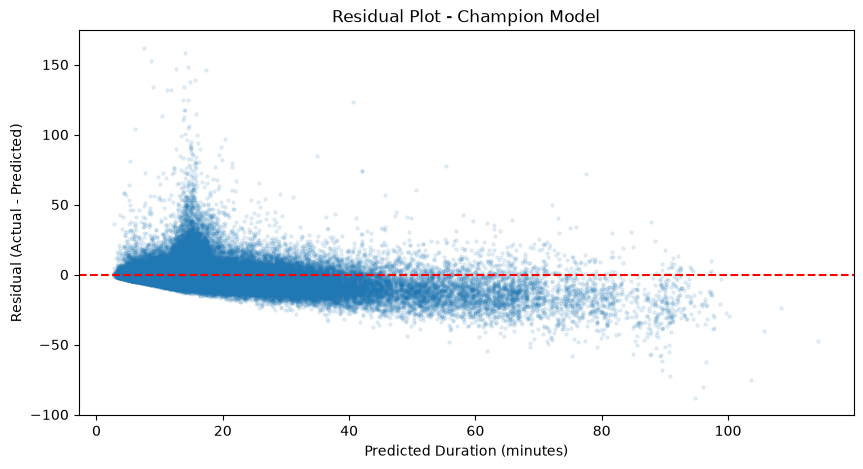

In [26]:
plt.figure(figsize=(10,5))
plt.scatter(test_results['predicted'], test_results['error'], alpha=0.1, s=5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Duration (minutes)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot - Champion Model')
plt.show()

In [27]:
print("Staten Island trips in test set:", (test_results['pickup_borough'] == 'Staten Island').sum())
print(test_results[test_results['pickup_borough'] == 'Staten Island']['trip_duration_minutes'].describe())

Staten Island trips in test set: 1
count      1.0
mean     162.5
std        NaN
min      162.5
25%      162.5
50%      162.5
75%      162.5
max      162.5
Name: trip_duration_minutes, dtype: float64


In [28]:
# Oracle: safe features + leakage features (post-trip data)
oracle_features_num = numeric_features_v2 + ['fare_amount', 'tip_amount', 'trip_distance', 'total_amount']

X_train_oracle = train[safe_features + ['route_median_duration','hour_route_median','fare_amount','tip_amount','trip_distance','total_amount']]
X_test_oracle = test[safe_features + ['route_median_duration','hour_route_median','fare_amount','tip_amount','trip_distance','total_amount']]

preprocessor_oracle = ColumnTransformer(transformers=[
    ('num', 'passthrough', oracle_features_num),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
])

oracle_pipeline = Pipeline(steps=[('preprocessor', preprocessor_oracle), 
                                    ('regressor', HistGradientBoostingRegressor(max_iter=100, random_state=42))])
oracle_pipeline.fit(X_train_oracle, y_train)
pred_oracle = oracle_pipeline.predict(X_test_oracle)
mae_oracle = mean_absolute_error(y_test, pred_oracle)

print("Safe Model (Champion) MAE:", mae_gb_v2)
print("Oracle Model MAE:", mae_oracle)
print(f"Oracle beats Safe by: {mae_gb_v2 - mae_oracle:.3f} minutes")

Safe Model (Champion) MAE: 5.83054060363656
Oracle Model MAE: 2.29962774736856
Oracle beats Safe by: 3.531 minutes
